# 03 — Previsão de recompra

Este notebook desenvolve um modelo de propensão à recompra para o projeto **Sales Intelligence AI**. A base transacional é transformada em atributos por cliente, e diferentes classificadores são comparados antes da geração dos artefatos utilizados pelo dashboard.

## 1. Carregamento e validação da base

A base comercial preparada no notebook anterior é carregada com `InvoiceDate` interpretada como data e `InvoiceNo` preservada como texto. Em seguida, `info()` e `head()` permitem conferir dimensões, tipos, valores ausentes e a estrutura dos primeiros registros antes da modelagem.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

vendas = pd.read_csv(
    "../data/vendas_limpas.csv",
    parse_dates=["InvoiceDate"],
    dtype={"InvoiceNo": str}
)

In [3]:
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  str           
 8   TotalPrice   524878 non-null  float64       
 9   Cancelled    524878 non-null  bool          
 10  Ano          524878 non-null  int64         
 11  Mes          524878 non-null  int64         
 12  AnoMes       524878 non-null  str           
 13  DiaSemana    524878 non-null  str           
 14  Hora         524878 non-null  int64         
dtypes: bool(1), datetime64[us](1), float64(3), in

In [4]:
vendas.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled,Ano,Mes,AnoMes,DiaSemana,Hora
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False,2010,12,2010-12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,2010,12,2010-12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False,2010,12,2010-12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,2010,12,2010-12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False,2010,12,2010-12,Wednesday,8


## 2. Definição da janela de recompra

A última data disponível é usada como referência para criar uma data de corte 30 dias antes. As transações até o corte formam o histórico utilizado na criação dos atributos; as transações posteriores representam a janela futura na qual se verifica se cada cliente voltou a comprar.

Essa separação temporal evita construir os atributos com informações que somente estariam disponíveis depois da data de previsão.

In [5]:
data_final = vendas["InvoiceDate"].max()

data_corte = data_final - pd.Timedelta(days=30)

print("Última data:", data_final)
print("Data de corte:", data_corte)

Última data: 2011-12-09 12:50:00
Data de corte: 2011-11-09 12:50:00


In [6]:
historico = vendas[
    vendas["InvoiceDate"] <= data_corte
].copy()

futuro = vendas[
    vendas["InvoiceDate"] > data_corte
].copy()

print("Registros históricos:", len(historico))
print("Registros futuros:", len(futuro))

Registros históricos: 437639
Registros futuros: 87239


## 3. Construção da base por cliente

O histórico transacional é agregado para produzir uma linha por cliente. São calculados recência, frequência, valor monetário, ticket médio, quantidade de produtos distintos, primeira compra e última compra. O tempo de relacionamento é medido entre a primeira compra e a data de corte.

A variável-alvo `Recomprou` recebe 1 quando o cliente aparece na janela futura de 30 dias e 0 caso contrário. A distribuição resultante é de aproximadamente **33,9% de recompra** e **66,1% de não recompra**, caracterizando desequilíbrio moderado entre as classes.

In [7]:
clientes_hist = (
    historico
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (data_corte - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum"),
        TicketMedio=("TotalPrice", "mean"),
        ProdutosDistintos=("StockCode", "nunique"),
        PrimeiraCompra=("InvoiceDate", "min"),
        UltimaCompra=("InvoiceDate", "max")
    )
)

In [8]:
clientes_hist["TempoCliente"] = (
    data_corte - clientes_hist["PrimeiraCompra"]
).dt.days

In [9]:
clientes_hist = clientes_hist.drop(
    columns=["PrimeiraCompra", "UltimaCompra"]
)

In [10]:
clientes_futuro = set(
    futuro["CustomerID"]
    .dropna()
    .unique()
)

In [11]:
clientes_hist["Recomprou"] = (
    clientes_hist.index.isin(clientes_futuro)
).astype(int)

In [12]:
clientes_hist.head()

,Recency,Frequency,Monetary,TicketMedio,ProdutosDistintos,TempoCliente,Recomprou
CustomerID,,,,,,,
12346.0,295,1,77183.60,77183.600000,1,295,0
12347.0,9,6,4085.18,23.889942,100,336,1
12348.0,44,4,1797.24,57.975484,22,327,0
12350.0,279,1,334.40,19.670588,17,279,0
12352.0,5,8,2506.04,29.482824,59,266,0


In [13]:
clientes_hist["Recomprou"].value_counts(normalize=True) * 100

Recomprou
0    66.093366
1    33.906634
Name: proportion, dtype: float64

## 4. Cálculo do ticket médio por pedido

O faturamento é primeiro agregado por cliente e `InvoiceNo`, garantindo que cada pedido seja tratado como uma unidade. Depois, calcula-se a média dos pedidos de cada cliente. Esse procedimento substitui a média por linha de item e produz uma representação comercialmente correta do ticket médio.

In [14]:
pedidos_hist = (
    historico
    .dropna(subset=["CustomerID"])
    .groupby(["CustomerID", "InvoiceNo"])["TotalPrice"]
    .sum()
    .reset_index()
)

In [15]:
ticket_medio_cliente = (
    pedidos_hist
    .groupby("CustomerID")["TotalPrice"]
    .mean()
)

In [16]:
clientes_hist["TicketMedio"] = ticket_medio_cliente

In [17]:
clientes_hist.head()

,Recency,Frequency,Monetary,TicketMedio,ProdutosDistintos,TempoCliente,Recomprou
CustomerID,,,,,,,
12346.0,295,1,77183.60,77183.600000,1,295,0
12347.0,9,6,4085.18,680.863333,100,336,1
12348.0,44,4,1797.24,449.310000,22,327,0
12350.0,279,1,334.40,334.400000,17,279,0
12352.0,5,8,2506.04,313.255000,59,266,0


## 5. Seleção dos atributos preditivos

A matriz de entrada reúne `Recency`, `Frequency`, `Monetary`, `TicketMedio`, `ProdutosDistintos` e `TempoCliente`. A variável-alvo é `Recomprou`. Esses atributos descrevem intensidade, valor, variedade e maturidade do relacionamento comercial antes da janela futura.

In [18]:
features_recompra = [
    "Recency",
    "Frequency",
    "Monetary",
    "TicketMedio",
    "ProdutosDistintos",
    "TempoCliente"
]

X = clientes_hist[features_recompra]
y = clientes_hist["Recomprou"]

## 6. Divisão entre treino e teste

Os clientes são divididos em 80% para treino e 20% para teste, com `random_state=42` para reprodutibilidade. O parâmetro `stratify=y` preserva a proporção das classes nos dois conjuntos, resultando em **3.256 clientes no treino e 814 no teste**.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nTreino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino: (3256, 6)
Teste: (814, 6)

Treino:
Recomprou
0    0.660934
1    0.339066
Name: proportion, dtype: float64

Teste:
Recomprou
0    0.660934
1    0.339066
Name: proportion, dtype: float64


## 7. Baseline de classificação

O baseline classifica todos os clientes como não recompradores, reproduzindo a classe majoritária. A acurácia obtida foi **66,09%**, mas precisão, recall e F1 para a classe positiva são nulos. Essa referência evidencia por que a acurácia isolada não é suficiente em bases desbalanceadas.

In [20]:
from sklearn.metrics import accuracy_score

baseline_pred = [0] * len(y_test)

accuracy_baseline = accuracy_score(
    y_test,
    baseline_pred
)

print(
    "Accuracy da baseline:",
    round(accuracy_baseline, 4)
)

Accuracy da baseline: 0.6609


## 8. Regressão logística

Os atributos são padronizados com `StandardScaler`, ajustado somente no treino e aplicado ao teste. A regressão logística utiliza pesos balanceados para compensar a diferença entre as classes. O modelo gera tanto a classificação final quanto a probabilidade estimada de recompra.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_log.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [22]:
pred_log = modelo_log.predict(X_test_scaled)

prob_log = modelo_log.predict_proba(X_test_scaled)[:, 1]

### Avaliação da regressão logística

O desempenho é avaliado por acurácia, precisão, recall, F1-score, ROC-AUC, relatório de classificação e matriz de confusão. A regressão logística alcançou **69,66% de acurácia**, **57,97% de recall**, **56,44% de F1** e **73,15% de ROC-AUC**, superando o baseline na identificação de recompradores.

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_log = accuracy_score(y_test, pred_log)
precision_log = precision_score(y_test, pred_log)
recall_log = recall_score(y_test, pred_log)
f1_log = f1_score(y_test, pred_log)
auc_log = roc_auc_score(y_test, prob_log)

print("Regressão Logística")
print("Accuracy:", round(accuracy_log, 4))
print("Precision:", round(precision_log, 4))
print("Recall:", round(recall_log, 4))
print("F1:", round(f1_log, 4))
print("ROC-AUC:", round(auc_log, 4))

Regressão Logística
Accuracy: 0.6966
Precision: 0.5498
Recall: 0.5797
F1: 0.5644
ROC-AUC: 0.7315


In [24]:
print(classification_report(y_test, pred_log))

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       538
           1       0.55      0.58      0.56       276

    accuracy                           0.70       814
   macro avg       0.66      0.67      0.67       814
weighted avg       0.70      0.70      0.70       814



In [25]:
confusion_matrix(y_test, pred_log)

array([[407, 131],
       [116, 160]])

## 9. Random Forest

A Random Forest captura relações não lineares e interações entre os atributos. A profundidade, o tamanho mínimo das folhas e o balanceamento das classes são controlados para reduzir sobreajuste. O modelo atingiu **71,13% de acurácia**, **63,41% de recall**, **59,83% de F1** e **74,45% de ROC-AUC**.

In [26]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [27]:
accuracy_rf = accuracy_score(y_test, pred_rf)
precision_rf = precision_score(y_test, pred_rf)
recall_rf = recall_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)
auc_rf = roc_auc_score(y_test, prob_rf)

print("Random Forest")
print("Accuracy:", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1:", round(f1_rf, 4))
print("ROC-AUC:", round(auc_rf, 4))

Random Forest
Accuracy: 0.7113
Precision: 0.5663
Recall: 0.6341
F1: 0.5983
ROC-AUC: 0.7445


In [28]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.75      0.77       538
           1       0.57      0.63      0.60       276

    accuracy                           0.71       814
   macro avg       0.68      0.69      0.69       814
weighted avg       0.72      0.71      0.71       814



In [29]:
confusion_matrix(y_test, pred_rf)

array([[404, 134],
       [101, 175]])

## 10. Comparação dos modelos

As métricas do baseline, da regressão logística e da Random Forest são reunidas em uma única tabela. A Random Forest apresentou o melhor conjunto de resultados, especialmente em recall, F1-score e ROC-AUC, e foi selecionada para gerar as probabilidades de recompra.

In [30]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regressão Logística",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_baseline,
        accuracy_log,
        accuracy_rf
    ],
    "Precision": [
        0,
        precision_log,
        precision_rf
    ],
    "Recall": [
        0,
        recall_log,
        recall_rf
    ],
    "F1": [
        0,
        f1_log,
        f1_rf
    ],
    "ROC_AUC": [
        0.5,
        auc_log,
        auc_rf
    ]
})

comparacao_modelos

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.660934,0.000000,0.000000,0.000000,0.500000
1,Regressão Logística,0.696560,0.549828,0.579710,0.564374,0.731453
2,Random Forest,0.711302,0.566343,0.634058,0.598291,0.744538


## 11. Importância das variáveis

A importância da Random Forest mostra a contribuição relativa dos atributos para as divisões das árvores. `Frequency` e `Monetary` foram as variáveis mais relevantes, seguidas por quantidade de produtos distintos e recência. A interpretação descreve o comportamento do modelo e não estabelece relação causal.

In [31]:
importancias_rf = pd.Series(
    modelo_rf.feature_importances_,
    index=features_recompra
).sort_values(ascending=False)

importancias_rf

Frequency            0.231773
Monetary             0.207200
ProdutosDistintos    0.172442
Recency              0.154290
TempoCliente         0.127520
TicketMedio          0.106776
dtype: float64

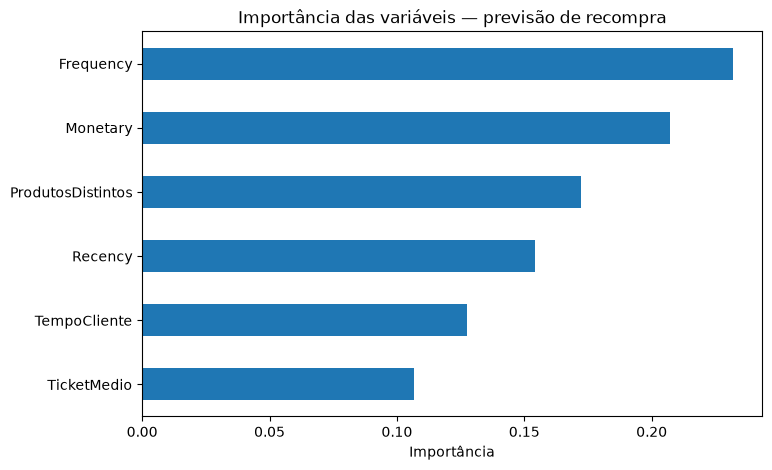

In [36]:
importancias_rf.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Importância das variáveis — previsão de recompra")
plt.xlabel("Importância")
plt.show()

## 12. Avaliação do threshold de classificação

Diferentes limites entre 0,30 e 0,70 são testados para transformar probabilidades em classes. O gráfico compara precisão, recall e F1-score em cada ponto, permitindo avaliar o compromisso entre identificar mais recompradores e reduzir falsos positivos. O threshold deve ser escolhido de acordo com o custo e a capacidade das ações comerciais.

In [37]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

resultados_threshold = []

for threshold in thresholds:
    pred_threshold = (prob_rf >= threshold).astype(int)

    resultados_threshold.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred_threshold),
        "Precision": precision_score(y_test, pred_threshold),
        "Recall": recall_score(y_test, pred_threshold),
        "F1": f1_score(y_test, pred_threshold)
    })

resultado_threshold = pd.DataFrame(resultados_threshold)

resultado_threshold

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.531941,0.410562,0.873188,0.558517
1,0.35,0.585995,0.439122,0.797101,0.566281
2,0.40,0.633907,0.474299,0.735507,0.576705
3,0.45,0.678133,0.518817,0.699275,0.595679
4,0.50,0.711302,0.566343,0.634058,0.598291
5,0.55,0.724816,0.604000,0.547101,0.574144
6,0.60,0.722359,0.620192,0.467391,0.533058
7,0.65,0.723587,0.654545,0.391304,0.489796
8,0.70,0.723587,0.688889,0.336957,0.452555


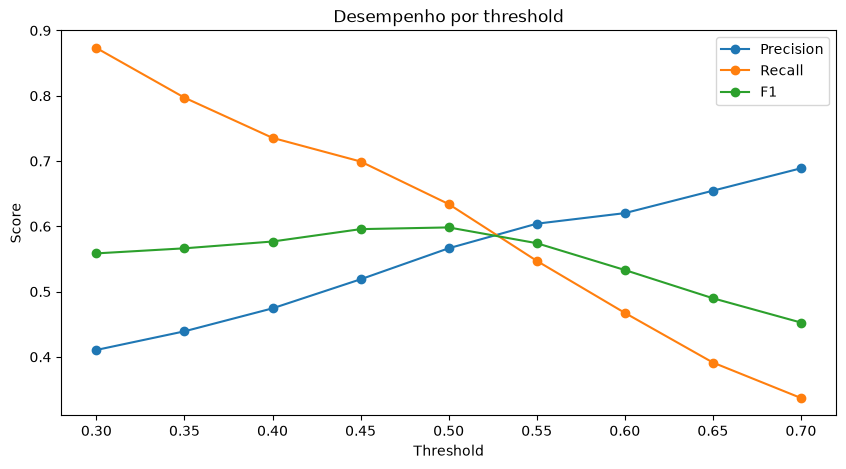

In [38]:
resultado_threshold.set_index("Threshold")[
    ["Precision", "Recall", "F1"]
].plot(
    figsize=(10, 5),
    marker="o"
)

plt.title("Desempenho por threshold")
plt.ylabel("Score")
plt.show()

## 13. Classificação das faixas de propensão

Para uso comercial, as probabilidades são convertidas em três faixas: **Alta** para valores a partir de 0,70, **Média** entre 0,40 e 0,70 e **Baixa** abaixo de 0,40. A carteira de teste é enriquecida com a probabilidade e o rótulo de propensão, ordenada do maior para o menor potencial e resumida por quantidade e percentual de clientes.

In [39]:
def classificar_propensao(prob):
    if prob >= 0.70:
        return "Alta"
    elif prob >= 0.40:
        return "Média"
    else:
        return "Baixa"

In [40]:
resultado_clientes = X_test.copy()

resultado_clientes["ProbabilidadeRecompra"] = prob_rf
resultado_clientes["Propensao"] = resultado_clientes[
    "ProbabilidadeRecompra"
].apply(classificar_propensao)

resultado_clientes.head()

,Recency,Frequency,Monetary,TicketMedio,ProdutosDistintos,TempoCliente,ProbabilidadeRecompra,Propensao
CustomerID,,,,,,,,
14903.0,94,4,2398.62,599.655000,195,248,0.680482,Média
15840.0,28,2,355.56,177.780000,26,142,0.443611,Média
13093.0,245,8,7832.47,979.058750,97,342,0.466557,Média
14976.0,26,7,790.86,112.980000,47,296,0.690835,Média
13021.0,7,7,1918.38,274.054286,67,328,0.806096,Alta


In [41]:
resultado_clientes = resultado_clientes.sort_values(
    "ProbabilidadeRecompra",
    ascending=False
)

In [42]:
resultado_clientes["Propensao"].value_counts()

Propensao
Baixa    386
Média    293
Alta     135
Name: count, dtype: int64

In [43]:
resultado_clientes["Propensao"].value_counts(normalize=True) * 100

Propensao
Baixa    47.420147
Média    35.995086
Alta     16.584767
Name: proportion, dtype: float64

## 14. Exportação da carteira priorizada

A tabela com atributos, probabilidade e faixa de propensão é exportada para `resultado_propensao.csv`. Esse arquivo é consumido pela aplicação Streamlit para permitir a exploração e priorização dos clientes.

In [44]:
resultado_clientes.to_csv(
    "../data/resultado_propensao.csv"
)

## 15. Persistência do modelo e dos atributos

O modelo Random Forest treinado e a lista ordenada de atributos são serializados com `joblib`. A persistência permite aplicar o mesmo modelo em novos clientes e garante que as colunas sejam fornecidas na ordem esperada durante a inferência.

In [46]:
import joblib

joblib.dump(
    modelo_rf,
    "../models/modelo_recompra_rf.pkl"
)

['../models/modelo_recompra_rf.pkl']

In [47]:
joblib.dump(
    features_recompra,
    "../models/features_recompra.pkl"
)

['../models/features_recompra.pkl']

## Conclusão da previsão de recompra

O pipeline transforma o histórico transacional em uma base supervisionada por cliente e avalia os modelos contra uma referência simples. A Random Forest apresentou o melhor desempenho entre as alternativas testadas, com **ROC-AUC de 74,45%**, **recall de 63,41%** e **F1-score de 59,83%**.

As probabilidades foram convertidas em faixas comerciais de propensão e exportadas para consumo no dashboard. Os resultados apoiam a priorização de clientes, mas devem ser interpretados como estimativas: o modelo depende da janela temporal escolhida e requer monitoramento e reavaliação antes de qualquer uso em produção.